# Proyecto 7 — Visualización básica con Pandas Plot / Matplotlib
### Laboratorio Práctico 2.1 · Ciencia de Datos · Equipo B (Data Storytelling y Visualización)

| | Original (Frank Andrade) | Adaptación (este notebook) |
|---|---|---|
| **Dataset** | `population_total.csv` (población por país y año) | `gapminder_full.csv` — Kaggle, *Gapminder World* (Tetiana Klimonova, CC0) |
| **Pregunta** | ¿Cómo creció la población de EE. UU., India, China, Indonesia y Brasil? | ¿Cómo cambió la **esperanza de vida** en Latinoamérica entre 1952 y 2007? |
| **Países** | United States, India, China, Indonesia, Brazil | Mexico, Brazil, Argentina, Colombia, Chile |
| **Gráficas interactivas** | `cufflinks` (`.iplot()`) | `plotly.express` (cufflinks no se actualiza desde 2020) |

**Concepto técnico que cubre:** el método `DataFrame.plot(kind=...)` de pandas, que usa Matplotlib por detrás. El truco del autor es **preparar primero el DataFrame con `pivot()`** (años en el índice, países en las columnas) para que cada gráfica salga con una sola línea de código.

> Fuente del código original: repositorio `thepycoach/curso-data-science`, carpeta `07.Visualizacion de Datos`; explicado en el video *Curso de Python para Data Science desde 0 (12 Horas)*, del minuto 4:59:32 al 6:15:31.

## 1. Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option('display.float_format', '{:,.2f}'.format)

## 2. Leer el dataset (Kaggle)
**Original:**
```python
df_population_raw = pd.read_csv('population_total.csv')
```
**Adaptado:** el archivo se descargó de Kaggle (*Gapminder World*). Trae 6 columnas en lugar de 3: además de población incluye continente, esperanza de vida (`life_exp`) y PIB per cápita (`gdp_cap`).

In [2]:
df_gap_raw = pd.read_csv('gapminder_full.csv')
df_gap_raw

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.80,779.45
1,Afghanistan,1957,9240934,Asia,30.33,820.85
2,Afghanistan,1962,10267083,Asia,32.00,853.10
3,Afghanistan,1967,11537966,Asia,34.02,836.20
4,Afghanistan,1972,13079460,Asia,36.09,739.98
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418,Africa,62.35,706.16
1700,Zimbabwe,1992,10704340,Africa,60.38,693.42
1701,Zimbabwe,1997,11404948,Africa,46.81,792.45
1702,Zimbabwe,2002,11926563,Africa,39.99,672.04


In [3]:
# Revisión rápida: tipos de dato y valores nulos por columna
df_gap_raw.info()
df_gap_raw.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     1704 non-null   object 
 1   year        1704 non-null   int64  
 2   population  1704 non-null   int64  
 3   continent   1704 non-null   object 
 4   life_exp    1704 non-null   float64
 5   gdp_cap     1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


country       0
year          0
population    0
continent     0
life_exp      0
gdp_cap       0
dtype: int64

## 3. Hacer la tabla pivote
`.pivot()` **reorganiza** el DataFrame (no agrega ni resume): pasa los valores de una columna al índice y los de otra a los nombres de columna.

**Original:**
```python
df_population_raw.dropna(inplace=True)
df_pivot = df_population_raw.pivot(index='year', columns='country', values='population')
df_pivot = df_pivot[['United States', 'India', 'China', 'Indonesia', 'Brazil']]
```
**Adaptado:** mismo patrón, cambiando `values` por `life_exp` y los países por cinco de Latinoamérica. `dropna(inplace=True)` se conserva como buena práctica aunque este dataset no tiene nulos.

In [4]:
df_gap_raw.dropna(inplace=True)

df_pivot = df_gap_raw.pivot(index='year', columns='country', values='life_exp')
df_pivot = df_pivot[['Mexico', 'Brazil', 'Argentina', 'Colombia', 'Chile']]
df_pivot

country,Mexico,Brazil,Argentina,Colombia,Chile
year,,,,,
1952,50.79,50.92,62.48,50.64,54.74
1957,55.19,53.28,64.40,55.12,56.07
1962,58.30,55.66,65.14,57.86,57.92
1967,60.11,57.63,65.63,59.96,60.52
1972,62.36,59.50,67.06,61.62,63.44
1977,65.03,61.49,68.48,63.84,67.05
1982,67.41,63.34,69.94,66.65,70.56
1987,69.50,65.20,70.77,67.77,72.49
1992,71.45,67.06,71.87,68.42,74.13


## 4. Lineplot (gráfico de línea)
Sirve para ver **tendencias en el tiempo**. Como el índice son los años y cada columna es un país, pandas dibuja una línea por país automáticamente.

**Original:**
```python
df_pivot.plot(kind='line', xlabel='Years', ylabel='Population',
              title='Population (1955-2020)', figsize=(8, 4))
```

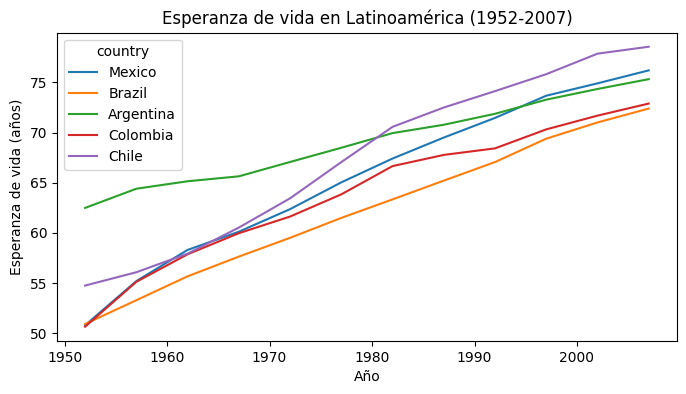

In [5]:
df_pivot.plot(kind='line', xlabel='Año', ylabel='Esperanza de vida (años)',
              title='Esperanza de vida en Latinoamérica (1952-2007)', figsize=(8, 4))
plt.show()

**Lectura:** los cinco países suben de forma sostenida. México, Brasil y Colombia parten cerca de 50 años, mientras Argentina ya estaba en 62. Para 2007 todos quedan entre 72 y 79 años, y Chile y México terminan por encima de Argentina.

## 5. Barplot (gráfico de barras)
### 5.1 Barplot de un solo año
Se filtra un año con `.index.isin([...])` y se **transpone** con `.T` para que los países queden en el índice (eje X) y el valor numérico en la columna.

**Original:**
```python
df_pivot_2020 = df_pivot[df_pivot.index.isin([2020])]
df_pivot_2020 = df_pivot_2020.T
df_pivot_2020.plot(kind='bar', color='orange', xlabel='Years', ylabel='Population',
                   title='Population 2020', figsize=(8, 4))
```
**Adaptado:** el dataset termina en 2007, así que ese es el año de corte.

In [6]:
df_pivot_2007 = df_pivot[df_pivot.index.isin([2007])]
df_pivot_2007 = df_pivot_2007.T
df_pivot_2007

year,2007
country,
Mexico,76.19
Brazil,72.39
Argentina,75.32
Colombia,72.89
Chile,78.55


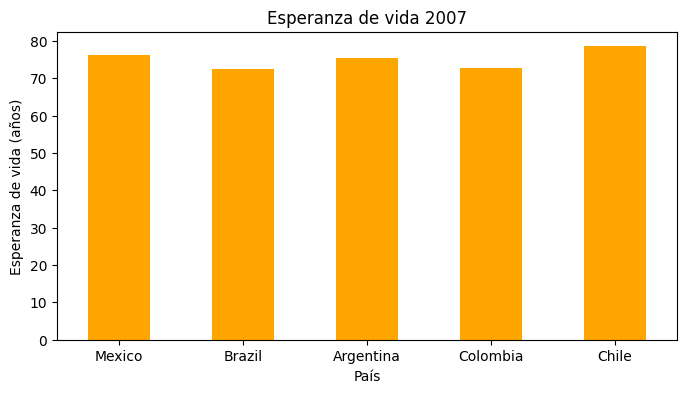

In [7]:
df_pivot_2007.plot(kind='bar', color='orange', xlabel='País', ylabel='Esperanza de vida (años)',
                   title='Esperanza de vida 2007', figsize=(8, 4), legend=False, rot=0)
plt.show()

### 5.2 Barplot agrupado por "n" variables
Con varios años no hace falta transponer: cada año (fila) se vuelve un grupo de barras y cada país un color.

**Original:**
```python
df_pivot_sample = df_pivot[df_pivot.index.isin([1980, 1990, 2000, 2010, 2020])]
df_pivot_sample.plot(kind='bar', xlabel='Years', ylabel='Population', figsize=(8, 4))
```

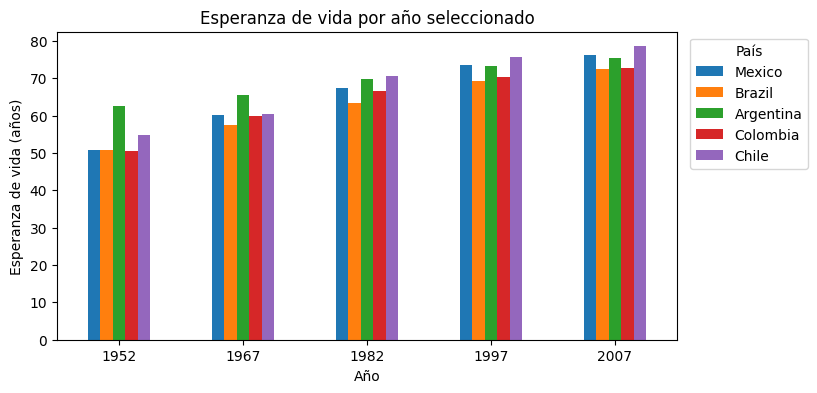

In [8]:
df_pivot_sample = df_pivot[df_pivot.index.isin([1952, 1967, 1982, 1997, 2007])]
df_pivot_sample.plot(kind='bar', xlabel='Año', ylabel='Esperanza de vida (años)',
                     title='Esperanza de vida por año seleccionado', figsize=(8, 4), rot=0)
plt.legend(title='País', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

## 6. Piechart (gráfico de pastel)
Un pastel solo tiene sentido cuando los valores son **partes de un todo**. La esperanza de vida no se suma entre países, así que para esta gráfica se usa la **población** de 2007 de los mismos cinco países (qué porcentaje aporta cada uno al total de los cinco).

**Original:**
```python
df_pivot_2020.rename(columns={2020: '2020'}, inplace=True)
df_pivot_2020.plot(kind='pie', y='2020', title='Population 2020', figsize=(8, 4))
```

In [9]:
df_pob_2007 = df_gap_raw.pivot(index='year', columns='country', values='population')
df_pob_2007 = df_pob_2007[['Mexico', 'Brazil', 'Argentina', 'Colombia', 'Chile']]
df_pob_2007 = df_pob_2007[df_pob_2007.index.isin([2007])].T

# El nombre de columna es el número 2007: se renombra a texto, como hace el autor
df_pob_2007.rename(columns={2007: '2007'}, inplace=True)
df_pob_2007

year,2007
country,
Mexico,108700891
Brazil,190010647
Argentina,40301927
Colombia,44227550
Chile,16284741


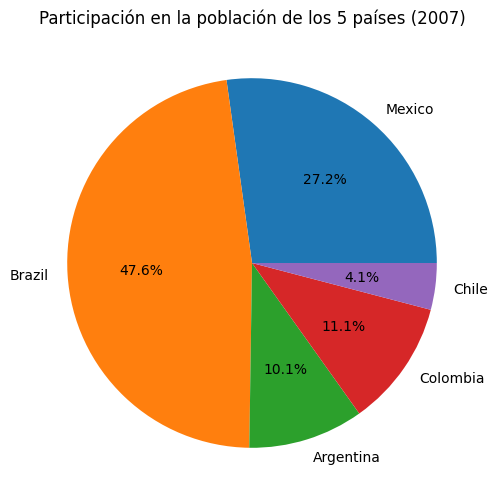

In [10]:
df_pob_2007.plot(kind='pie', y='2007', autopct='%1.1f%%', legend=False, ylabel='',
                 title='Participación en la población de los 5 países (2007)', figsize=(6, 6))
plt.show()

## 7. Boxplot (gráfico de caja)
Muestra la distribución: mínimo, primer cuartil (Q1), **mediana**, tercer cuartil (Q3), máximo y valores atípicos.

**Original:**
```python
df_pivot['United States'].plot(kind='box', color='green', ylabel='Population')
df_pivot.plot(kind='box', xlabel='Countries', ylabel='Population')
```
### 7.1 Un solo boxplot

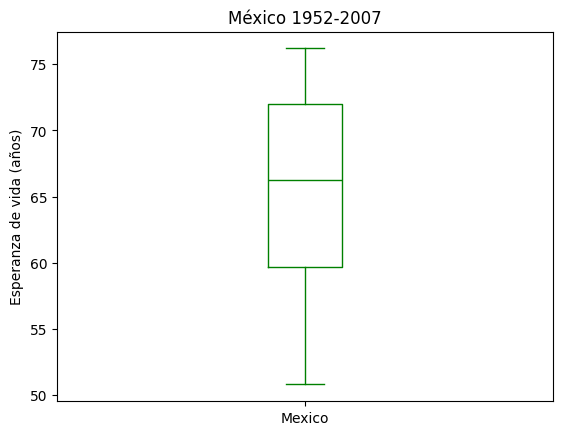

In [11]:
df_pivot['Mexico'].plot(kind='box', color='green', ylabel='Esperanza de vida (años)',
                        title='México 1952-2007')
plt.show()

### 7.2 Múltiples boxplots

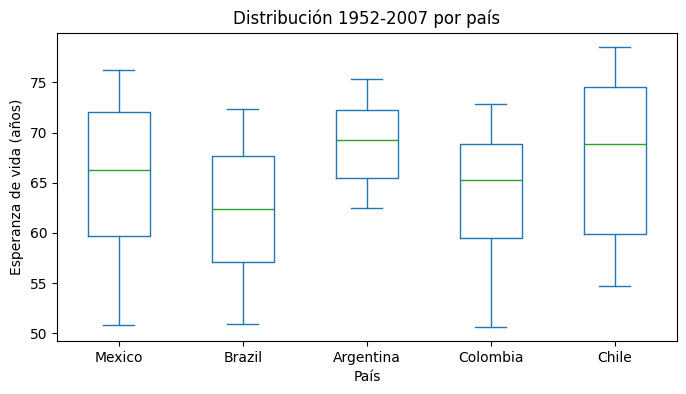

In [12]:
df_pivot.plot(kind='box', xlabel='País', ylabel='Esperanza de vida (años)',
              title='Distribución 1952-2007 por país', figsize=(8, 4))
plt.show()

**Lectura:** Argentina tiene la caja más corta (menos variación: ya partía alta en 1952); México y Chile tienen las más largas porque fueron los que más años ganaron en el periodo.

## 8. Histograma
Muestra la **frecuencia**: cuántos datos caen en cada intervalo (*bins*).

**Original:**
```python
df_pivot[['United States', 'Indonesia']].plot(kind='hist', xlabel='Population', figsize=(8, 4))
```
**Adaptado:** con solo 12 años por país un histograma queda muy pobre, así que se reutiliza `pivot()` para comparar la esperanza de vida de **todos los países de África contra todos los de Europa en 2007** (52 y 30 países).

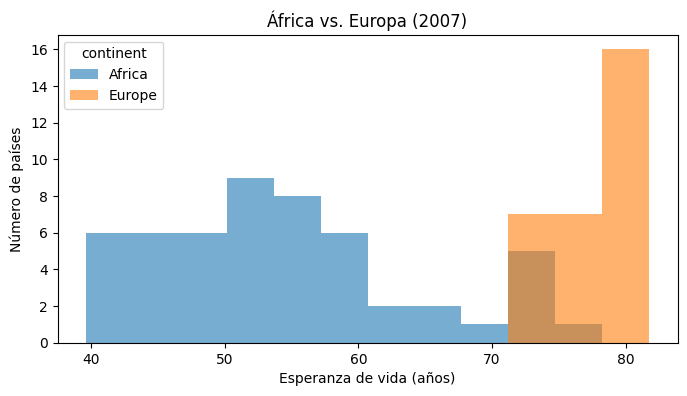

In [13]:
df_2007 = df_gap_raw[df_gap_raw['year'] == 2007]
df_cont = df_2007.pivot(index='country', columns='continent', values='life_exp')
df_cont[['Africa', 'Europe']].plot(kind='hist', bins=12, alpha=0.6,
                                   xlabel='Esperanza de vida (años)', ylabel='Número de países',
                                   title='África vs. Europa (2007)', figsize=(8, 4))
plt.show()

**Lectura:** las distribuciones casi no se traslapan: todos los países europeos están arriba de 71 años, mientras que la mediana africana es de unos 53 años.

## 9. ScatterPlot (gráfico de dispersión)
Sirve para ver la **relación entre dos variables numéricas**.

**Original:**
```python
df_sample = df_population_raw[df_population_raw['country'].isin(['United States', 'India', 'China', 'Indonesia', 'Brazil'])]
df_sample.plot(kind='scatter', x='year', y='population', figsize=(8, 4))
```
**Adaptado:** en vez de año contra población se compara **PIB per cápita contra esperanza de vida** para los 142 países en 2007. El eje X va en escala logarítmica (`logx=True`) porque el PIB va de ~280 a ~49,000 dólares.

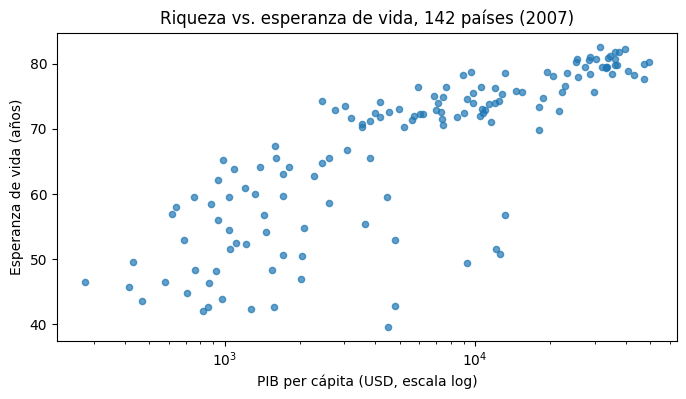

In [14]:
df_2007.plot(kind='scatter', x='gdp_cap', y='life_exp', logx=True, alpha=0.7,
             xlabel='PIB per cápita (USD, escala log)', ylabel='Esperanza de vida (años)',
             title='Riqueza vs. esperanza de vida, 142 países (2007)', figsize=(8, 4))
plt.show()

In [15]:
# Qué tan fuerte es la relación (coeficiente de correlación de Pearson)
df_2007[['gdp_cap', 'life_exp']].corr()

,gdp_cap,life_exp
gdp_cap,1.00,0.68
life_exp,0.68,1.00


## 10. Guardar el plot y exportar la tabla pivote
**Original:**
```python
df_pivot.to_excel('pivot_table.xlsx')
df_pivot.plot(kind='line', ...)
plt.savefig('my_test.png')
```

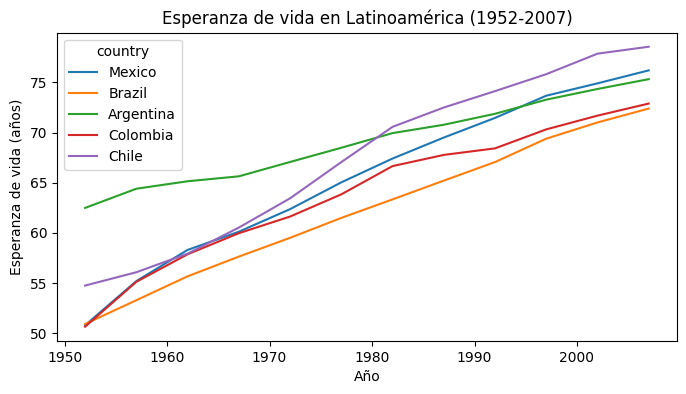

In [16]:
df_pivot.to_excel('tabla_pivote_esperanza_vida.xlsx')

df_pivot.plot(kind='line', xlabel='Año', ylabel='Esperanza de vida (años)',
              title='Esperanza de vida en Latinoamérica (1952-2007)', figsize=(8, 4))
plt.savefig('grafica_esperanza_vida.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Visualización interactiva
**Original** (librería `cufflinks`):
```python
import cufflinks as cf
cf.set_config_file(sharing='public', theme='white', offline=True)
df_population.iplot(kind='line', xTitle='Years', yTitle='Population', title='Population (1955-2020)')
```
**Problema encontrado:** `cufflinks` no está instalado por defecto y su última versión es de **marzo de 2020**; al ejecutar el notebook original falla con `ModuleNotFoundError`. **Solución:** usar `plotly.express`, la interfaz actual de Plotly (la misma librería que `cufflinks` usaba por dentro).

In [17]:
fig = px.line(df_pivot, labels={'value': 'Esperanza de vida (años)', 'year': 'Año', 'country': 'País'},
              title='Esperanza de vida en Latinoamérica (1952-2007) — interactivo')
fig.show()

In [18]:
# Versión "Hans Rosling": dispersión animada año por año, 142 países
fig = px.scatter(df_gap_raw, x='gdp_cap', y='life_exp', size='population', color='continent',
                 hover_name='country', animation_frame='year', log_x=True, size_max=45,
                 range_x=[200, 60000], range_y=[20, 90],
                 labels={'gdp_cap': 'PIB per cápita (USD)', 'life_exp': 'Esperanza de vida'},
                 title='Riqueza vs. esperanza de vida 1952-2007')
fig.write_html('grafica_interactiva_gapminder.html', include_plotlyjs='cdn')
fig.show()

## 12. ¿Qué pasa si...? (experimentos para la defensa técnica)
Cambios de un solo parámetro para mostrar que se entiende qué controla cada argumento.

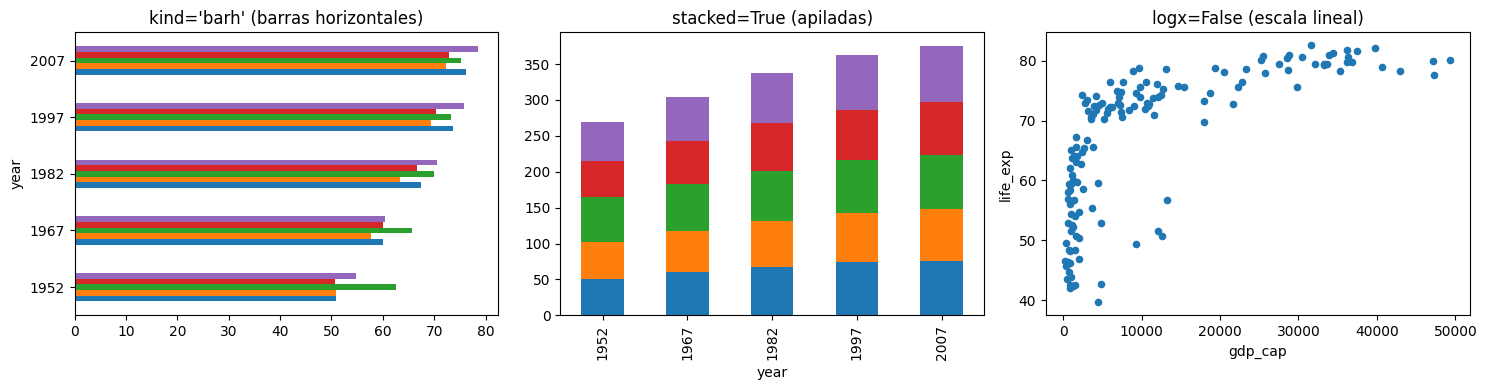

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_pivot_sample.plot(kind='barh', ax=axes[0], title="kind='barh' (barras horizontales)", legend=False)
df_pivot_sample.plot(kind='bar', stacked=True, ax=axes[1], title='stacked=True (apiladas)', legend=False)
df_2007.plot(kind='scatter', x='gdp_cap', y='life_exp', ax=axes[2], title='logx=False (escala lineal)')
plt.tight_layout()
plt.show()

- `kind='barh'`: mismas barras pero horizontales; útil cuando las etiquetas son largas.
- `stacked=True`: apila los países; aquí **no tiene sentido** porque sumar esperanzas de vida no significa nada, aunque en población sí lo tendría.
- `logx=False`: sin escala logarítmica los países pobres se amontonan a la izquierda y la curva parece "doblarse"; la escala log la vuelve casi una recta.

## 13. Conclusiones
1. **Preparar los datos es la mitad de la gráfica:** con el DataFrame en forma "años × países" (vía `pivot`), cada tipo de gráfico sale con `df.plot(kind=...)`, exactamente como enseña el autor.
2. **El código se adaptó con cambios mínimos** (`values`, lista de países y año de corte), lo que muestra que el patrón es reutilizable con cualquier dataset con estructura entidad-tiempo-valor.
3. **No todo gráfico sirve para cualquier dato:** el pastel se hizo con población y no con esperanza de vida, y el histograma se cambió a una comparación entre continentes porque 12 años por país no forman una distribución útil.
4. **Hallazgo de datos:** entre 1952 y 2007 los cinco países latinoamericanos ganaron entre 13 (Argentina) y 25 años (México) de esperanza de vida. A nivel mundial la esperanza de vida crece con el PIB per cápita: la correlación es 0.68 en escala lineal y sube a 0.81 al usar el logaritmo del PIB, por eso la escala log describe mejor la relación.
5. **Mantenimiento de librerías:** `cufflinks` ya no funciona sin instalación extra y está abandonada; `plotly.express` es el reemplazo actual.